# Population and sample 

This notebook aims to demonstrate the importance of sampling and population in various situation.  We demonstrate how Laplace estimated the population of France, using Hogwarts, fictional characters.

# Data and library

In [1]:

import numpy as np # linear algebra
from numpy import var
from numpy import mean
from math import sqrt
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import random 
import os
import matplotlib.pyplot as plt

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/samples/samples_hp.csv
/kaggle/input/united-kingdom-real-estate-and-population-data/data.csv
/kaggle/input/geonames-gb/geo_locations.csv
/kaggle/input/geonames-gb/location_with_grouping.csv
/kaggle/input/geonames-gb/monthly_aggregations.csv
/kaggle/input/samples-v2/samples_hp.csv


In [2]:
def cohend(d1, d2):
	# calculate the size of samples
	n1, n2 = len(d1), len(d2)
	# calculate the variance of the samples
	s1, s2 = var(d1, ddof=1), var(d2, ddof=1)
	# calculate the pooled standard deviation
	s = sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
	# calculate the means of the samples
	u1, u2 = mean(d1), mean(d2)
	# calculate the effect size
	return (u1 - u2) / s

# Estimation of Hogwarts population

We generated the list of characters in the _Philosopher stone_ and the _Deathly hallows_, using Gemini, Flash 2.0 model, on the 7th of June 2025.

In [3]:
samples = pd.read_csv('/kaggle/input/samples/samples_hp.csv')
print(samples.dtypes)
samples.shape

Philosopher stones    object
Deathly Hallows       object
dtype: object


(27, 2)

In [4]:
samples

,Philosopher stones,Deathly Hallows
0,Harry Potter,Neville LongBottom
1,Hermione Granger,Ginny Weasley
2,Ron Weasley,Seamus Finnigan
3,Neville Longbottom,Dean Thomas
4,Seamus Finnigan,Lavender Brown
5,Dean Thomas,Parvati Patil
6,Lavender Brown,Colin Creevey
7,Parvati Patil,Dennis Creevey
8,Draco Malfoy,Lee Jordan
9,Vincent Crabbe,Ernie Macmillan


We count the number of common pupils in both books.

In [5]:
year_1 = set(samples['Philosopher stones'].str.upper())
year_6 = set(samples['Deathly Hallows'].str.upper())
common_pupils = year_1 & year_6
count_both = len(common_pupils)
count_both

18

In [6]:
common_pupils

{'ANTHONY GOLDSTEIN',
 'BLAISE ZABINI',
 'DAPHNE GREENGRASS',
 'DEAN THOMAS',
 'DRACO MALFOY',
 'ERNIE MACMILLAN',
 'GREGORY GOYLE',
 'HANNAH ABBOTT',
 'JUSTIN FINCH-FLETCHLEY',
 'LAVENDER BROWN',
 'MICHAEL CORNER',
 'NEVILLE LONGBOTTOM',
 'PARVATI PATIL',
 'SEAMUS FINNIGAN',
 'SUSAN BONES',
 'TERRY BOOT',
 'THEODORE NOTT',
 'VINCENT CRABBE'}

We count the number of pupils in the first book, but not in the last one. 

In [7]:
only_year_1 = year_1.difference(year_6)
count_only_year_1 = len(only_year_1)
count_only_year_1

9

In [8]:
only_year_1

{'HARRY POTTER',
 'HERMIONE GRANGER',
 'LISA TURPIN',
 'MANDY BROCKLEHURST',
 'MILLICENT BULSTRODE',
 'MORAG MACDOUGAL',
 'PADMA PATIL',
 'PANSY PARKINSON',
 'RON WEASLEY'}

We count the number of pupils in the last book, but not in the first one. 

In [9]:
only_year_6 = year_6.difference(year_1)
count_only_year_6 = len(only_year_6)
count_only_year_6

9

In [10]:
only_year_6

{'CHO CHANG',
 'COLIN CREEVEY',
 'DENNIS CREEVEY',
 'GINNY WEASLEY',
 'LEE JORDAN',
 'LUNA LOVEGOOD',
 'PADMA PATIL:',
 'PANSY PARKINSON:',
 'ZACHARIAS SMITH'}

Estimation of the population: 

$U$  is the total number of pupils in the first book

$V$  is the total number of pupils in the last book

$W$  is the number of pupils observed in both books

$\widehat{N} = \frac{UV}{W}$


In [11]:
U = len(year_1)
U

27

In [12]:
V = len(year_6)
V

27

In [13]:
W = count_both
W

18

In [14]:
N = (U * V)/W
N

40.5

# Estimating the prices of Cambridge properties values using some samples

We use some large data about properties to illustrate the size of sample matters.  We use several methods of sampling as illustrated in [this post](https://medium.com/@ayanchowdhury00/sampling-techniques-and-its-implementation-in-python-487995b9399c).


We experiment to demonstrate the use of the Central Limit Theorem. The Central Limit Theorem (CLT) surmises that __the average of the sample means and standard deviations equals the population mean and standard deviation__. When n>30.

## Upload the data

In [15]:
plt.rcParams["figure.figsize"] = (20,10)

In [16]:
path = '/kaggle/input/united-kingdom-real-estate-and-population-data/data.csv'
data = pd.read_csv('/kaggle/input/united-kingdom-real-estate-and-population-data/data.csv')
data.shape

(7853837, 13)

In [17]:
data.dtypes

Unnamed: 0            int64
Code                 object
Name                 object
Geography            object
Area (sq km)        float64
Price                 int64
Date of Transfer     object
Property Type        object
Old/New              object
Duration             object
PPDCategory Type     object
pp_sq_m             float64
est_pop             float64
dtype: object

In [18]:
data.describe()

,Unnamed: 0,Area (sq km),Price,pp_sq_m,est_pop
count,7.853837e+06,7.853837e+06,7.853837e+06,7.853837e+06,5.208853e+06
mean,5.431394e+06,4.194698e+02,2.209744e+05,2.599774e+03,1.372225e+06
std,3.154738e+06,5.338312e+02,5.708082e+05,1.613246e+03,2.584126e+06
min,1.282500e+04,1.631770e+01,1.000000e+00,9.704739e+01,2.140000e+03
25%,2.674884e+06,7.461320e+01,1.025000e+05,9.843264e+02,1.340490e+05
50%,5.370908e+06,1.581281e+02,1.550000e+05,2.608139e+03,2.380160e+05
75%,8.102541e+06,4.144144e+02,2.407510e+05,4.011644e+03,4.418580e+05
max,1.083096e+07,1.572031e+03,9.890000e+07,5.218986e+03,7.322403e+06


We filter the rows for Cambridge

In [19]:
filter_rows = data.Name.str.contains("CAMBRIDGE")
filter_cols = ['Price']
population = data.loc[filter_rows, filter_cols]
pop_mean = population.mean()["Price"]
pop_std = population.std()["Price"]

population.describe()

,Price
count,7.158900e+04
mean,2.887456e+05
std,2.916205e+05
min,1.000000e+02
25%,1.700000e+05
50%,2.360000e+05
75%,3.350000e+05
max,2.237400e+07


In [20]:
population = population.Price.tolist()
len(population)

71589

# Random sample


### Sample no 1 : 10 items 

In [21]:
sample_sizes= int(1e1)
sample =  pd.Series(random.sample(population, sample_sizes))
sample_mean = sample.mean()
sample_std  = sample.std(ddof = 1)
print("Population mean                : " , pop_mean)
print("Population standard deviation  : " , pop_std)
print("Sample mean                    : " , sample_mean)
print("Sample standard deviation      : " , sample_std)


Population mean                :  288745.5937364679
Population standard deviation  :  291620.51628526766
Sample mean                    :  349895.0
Sample standard deviation      :  215350.97766978756


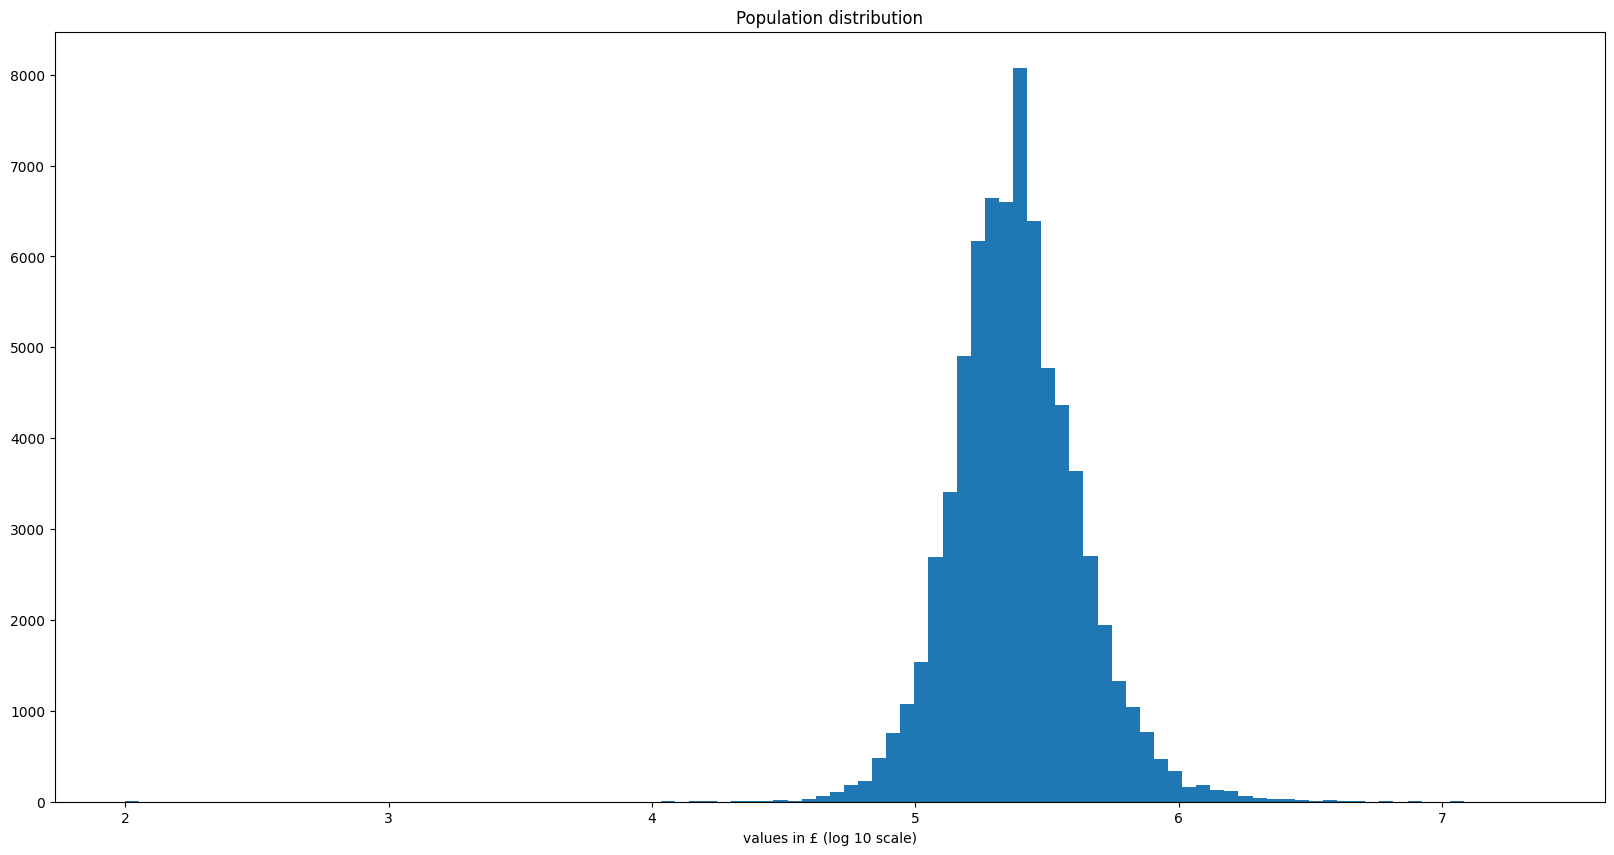

In [22]:
# Generate two normal distributions
dist1 = np.log10(population)
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist1, bins=100)
plt.title('Population distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

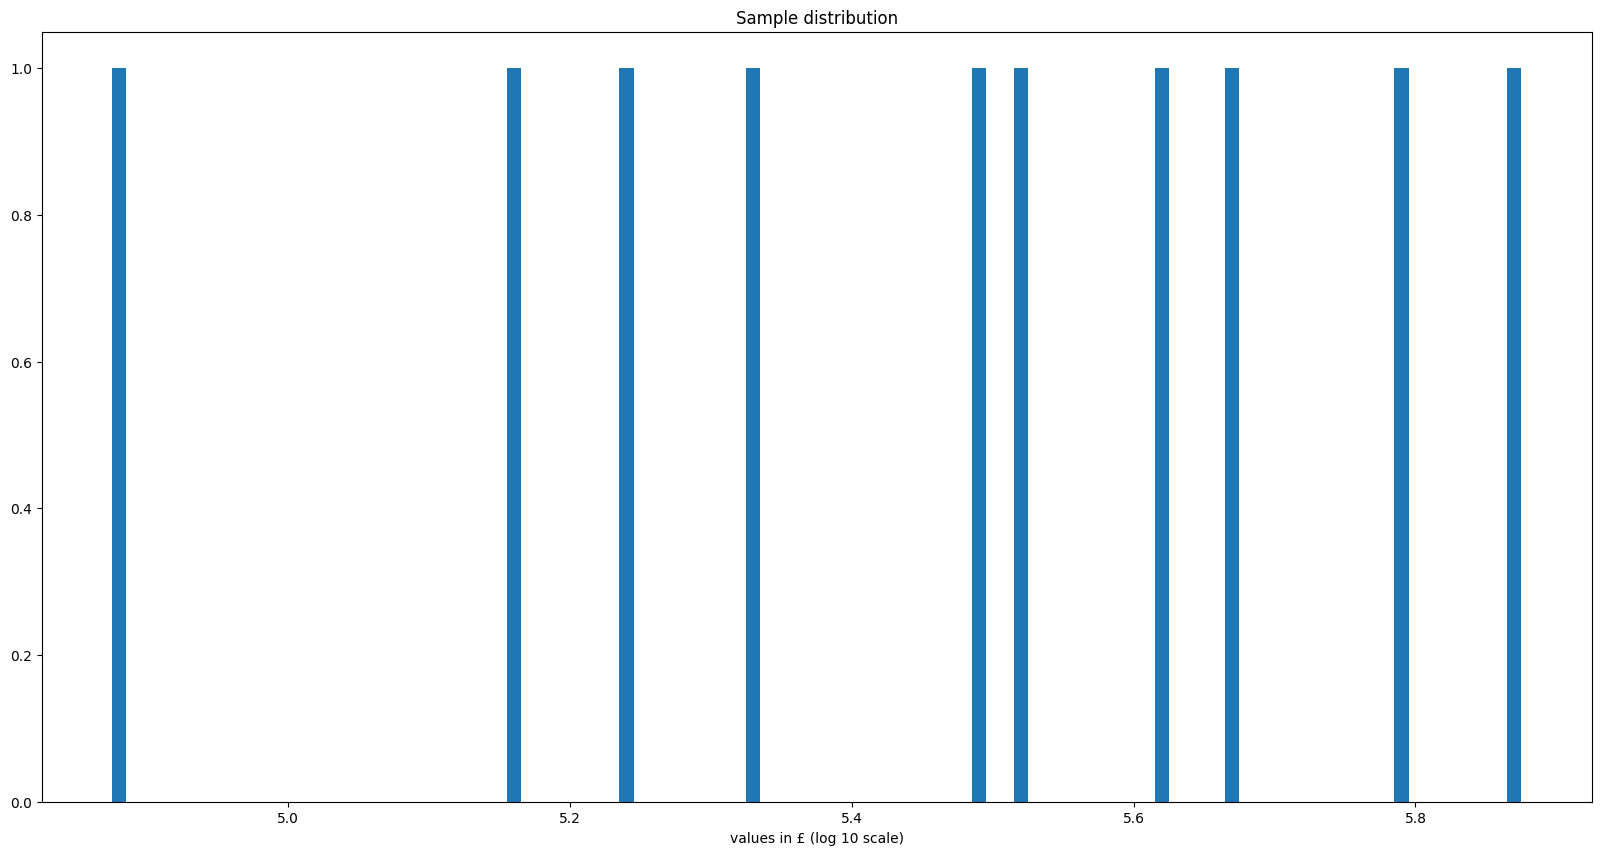

In [23]:
# Generate two normal distributions
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist2, bins=100)
plt.title('Sample distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

We compute the effect size. 

In [24]:

d = cohend(population, sample)
print('Cohens d: %.3f' % d)

Cohens d: -0.210


### Sample no 2 : 100 items



In [25]:
sample_sizes= int(1e2)
sample =  pd.Series(random.sample(population, sample_sizes))
sample_mean = sample.mean()
sample_std  = sample.std(ddof = 1)
print("Population mean                : " , pop_mean)
print("Population standard deviation  : " , pop_std)
print("Sample mean                    : " , sample_mean)
print("Sample standard deviation      : " , sample_std)


Population mean                :  288745.5937364679
Population standard deviation  :  291620.51628526766
Sample mean                    :  282045.34
Sample standard deviation      :  228950.5972163023


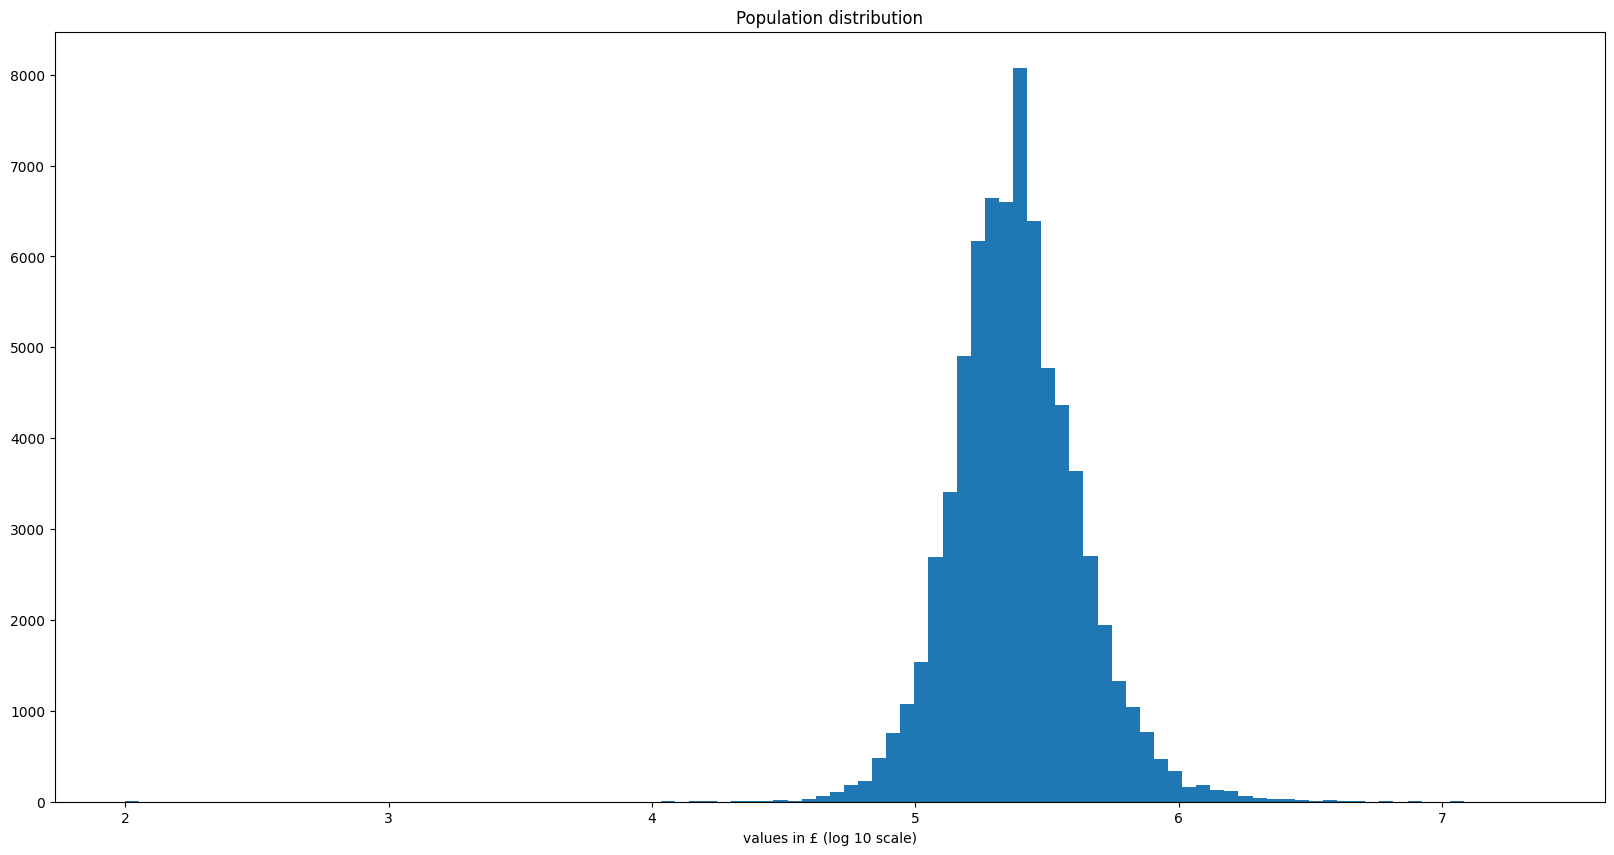

In [26]:
# Generate two normal distributions
dist1 = np.log10(population)
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist1, bins=100)
plt.title('Population distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

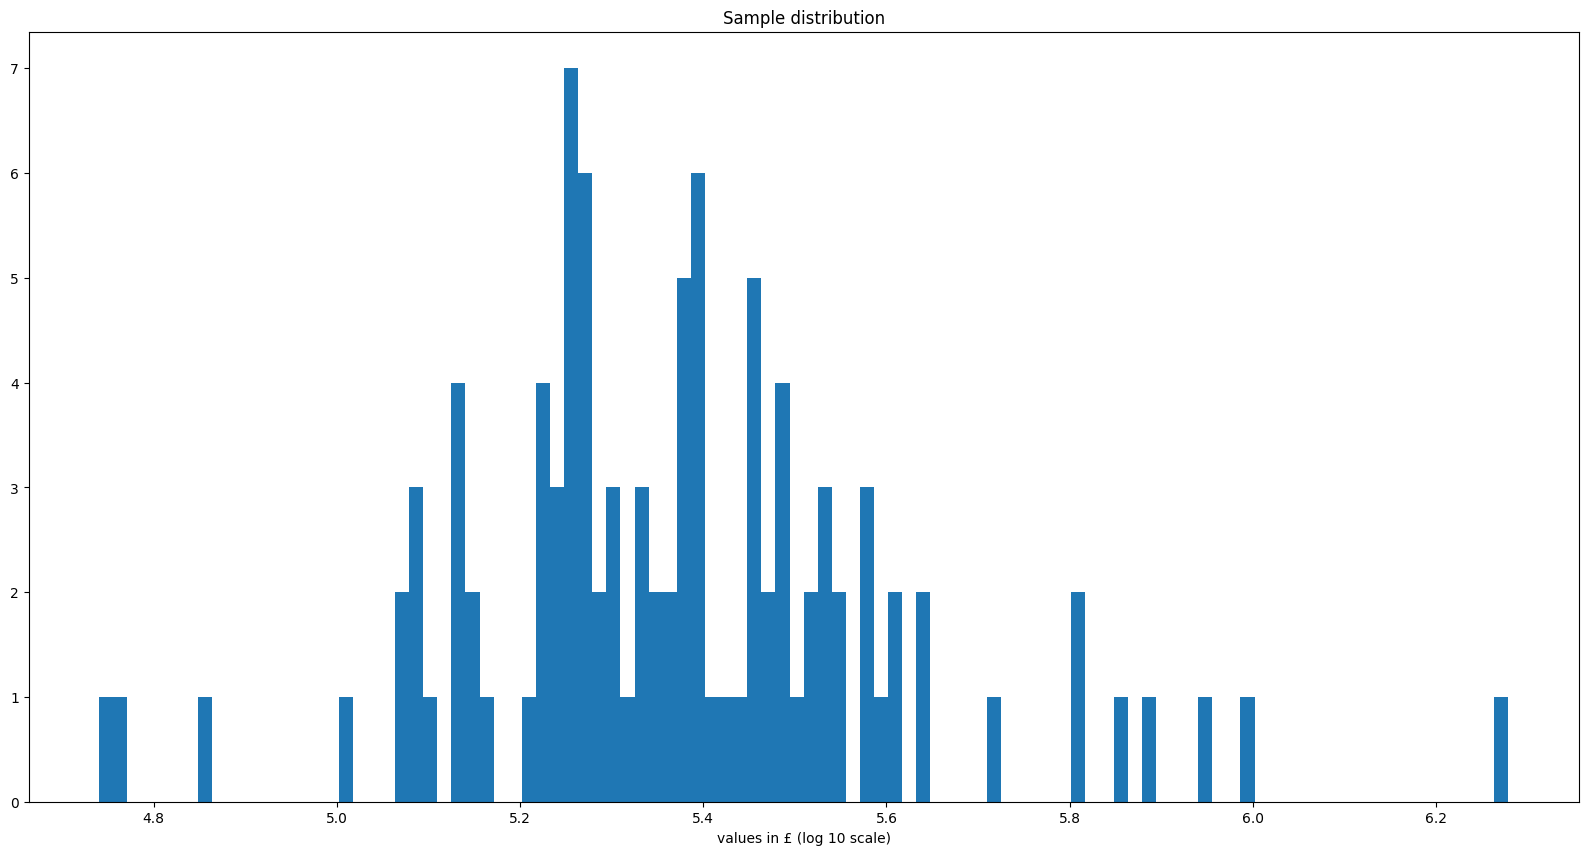

In [27]:
# Generate two normal distributions
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist2, bins=100)
plt.title('Sample distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

In [28]:

d = cohend(population, sample)
print('Cohens d: %.3f' % d)

Cohens d: 0.023


### Sample no 3 : 1000 items



In [29]:
sample_sizes= int(1e3)
sample =  pd.Series(random.sample(population, sample_sizes))
sample_mean = sample.mean()
sample_std  = sample.std(ddof = 1)
print("Population mean                : " , pop_mean)
print("Population standard deviation  : " , pop_std)
print("Sample mean                    : " , sample_mean)
print("Sample standard deviation      : " , sample_std)


Population mean                :  288745.5937364679
Population standard deviation  :  291620.51628526766
Sample mean                    :  278001.442
Sample standard deviation      :  217598.52087878005


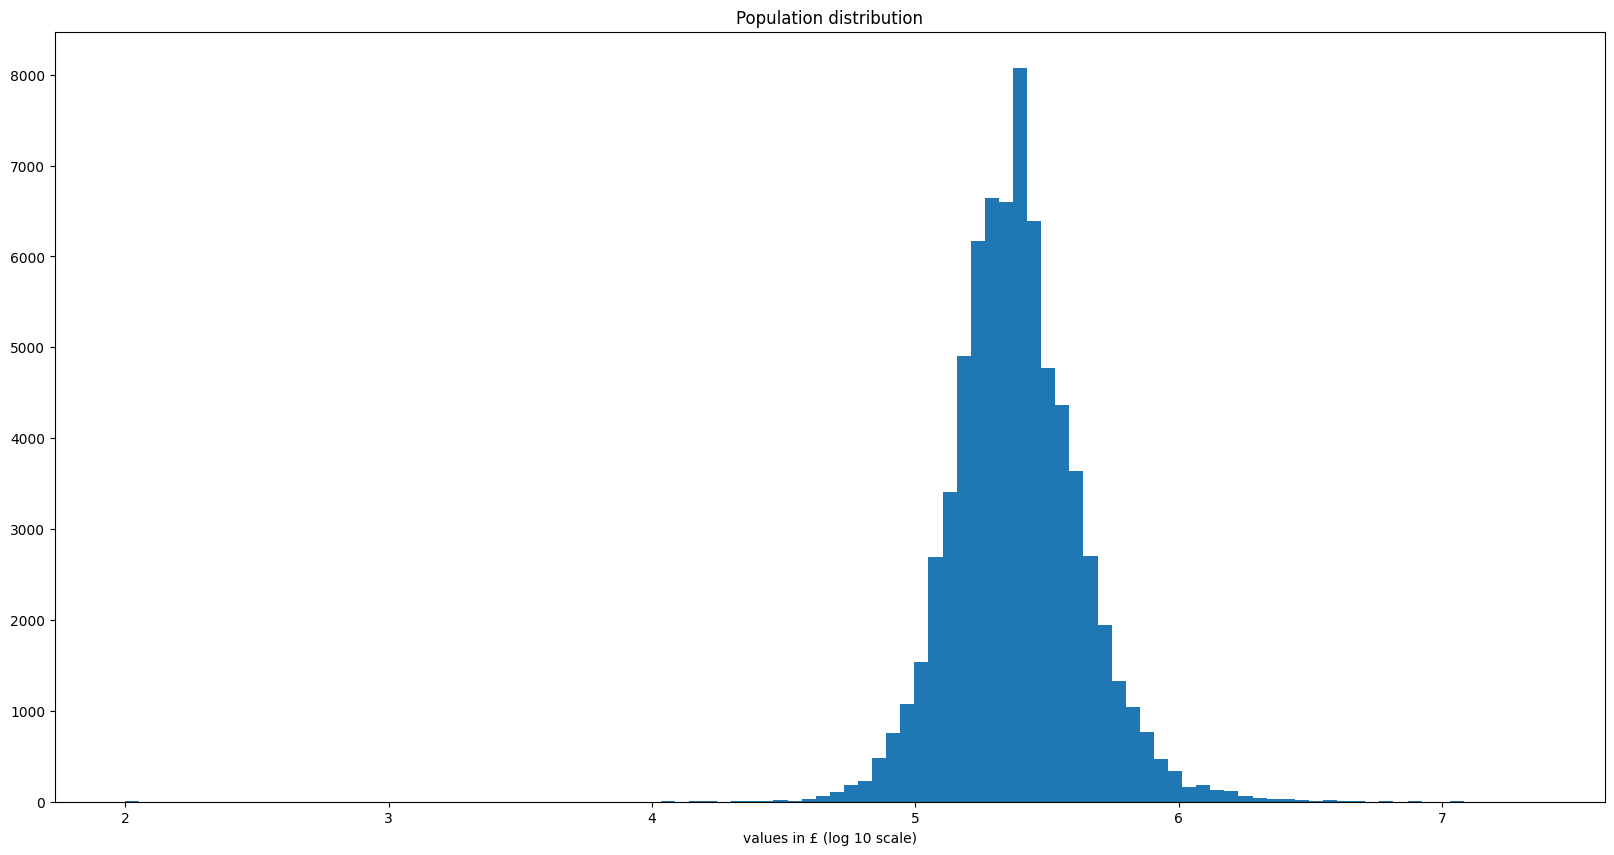

In [30]:
# Generate two normal distributions
dist1 = np.log10(population)
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist1, bins=100)
plt.title('Population distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

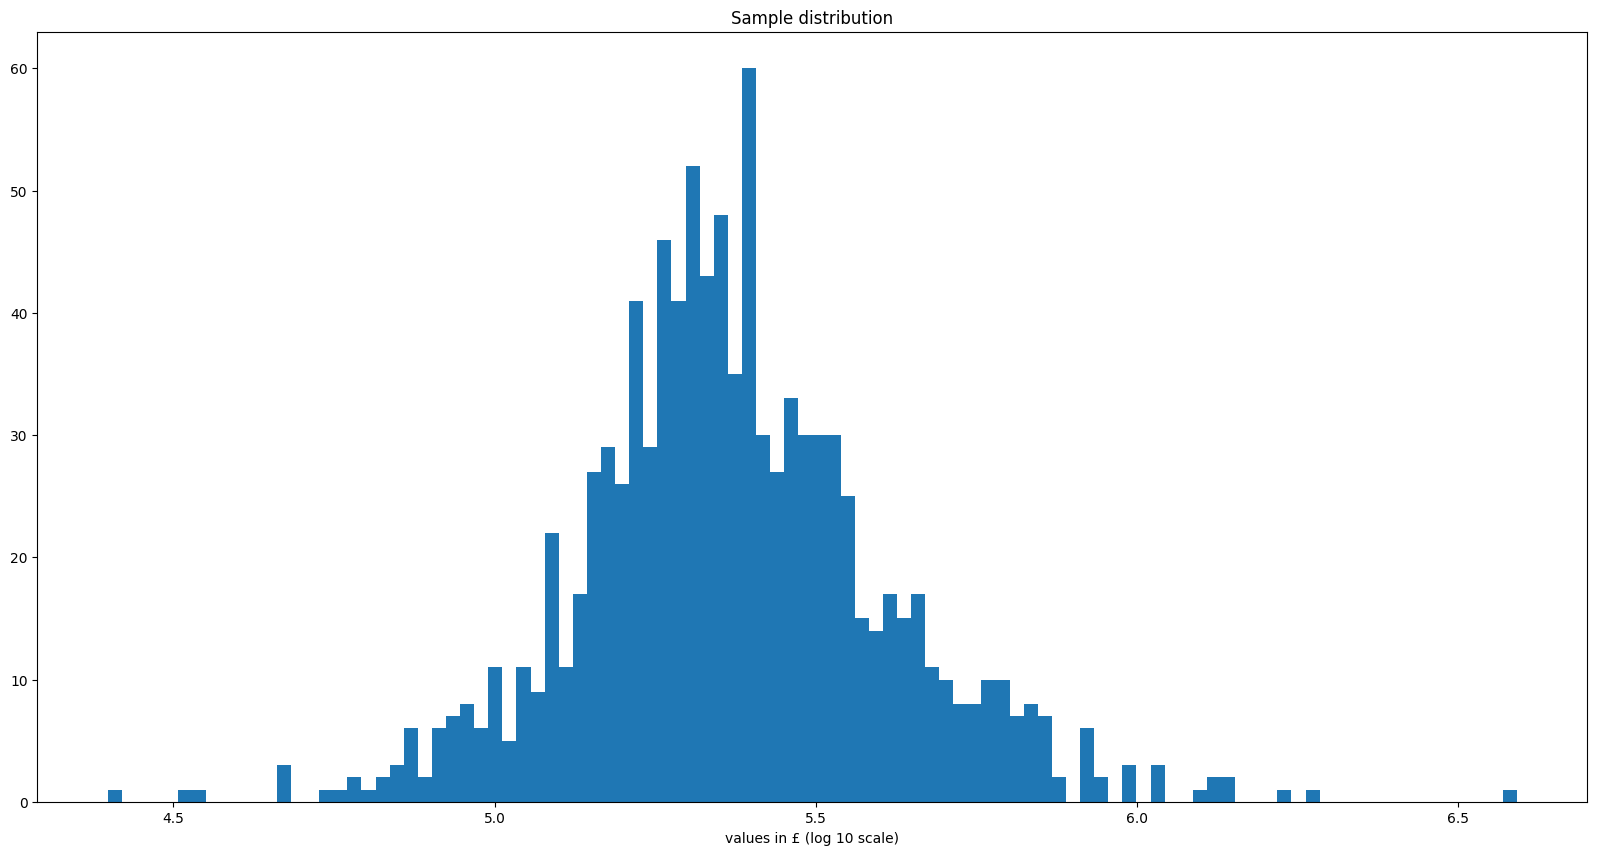

In [31]:
# Generate two normal distributions
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist2, bins=100)
plt.title('Sample distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

In [32]:

d = cohend(population, sample)
print('Cohens d: %.3f' % d)

Cohens d: 0.037


### Sample no 4 : 10000 items



In [33]:
sample_sizes= int(1e4)
sample =  pd.Series(random.sample(population, sample_sizes))
sample_mean = sample.mean()
sample_std  = sample.std(ddof = 1)
print("Population mean                : " , pop_mean)
print("Population standard deviation  : " , pop_std)
print("Sample mean                    : " , sample_mean)
print("Sample standard deviation      : " , sample_std)


Population mean                :  288745.5937364679
Population standard deviation  :  291620.51628526766
Sample mean                    :  288366.7616
Sample standard deviation      :  249803.84539381036


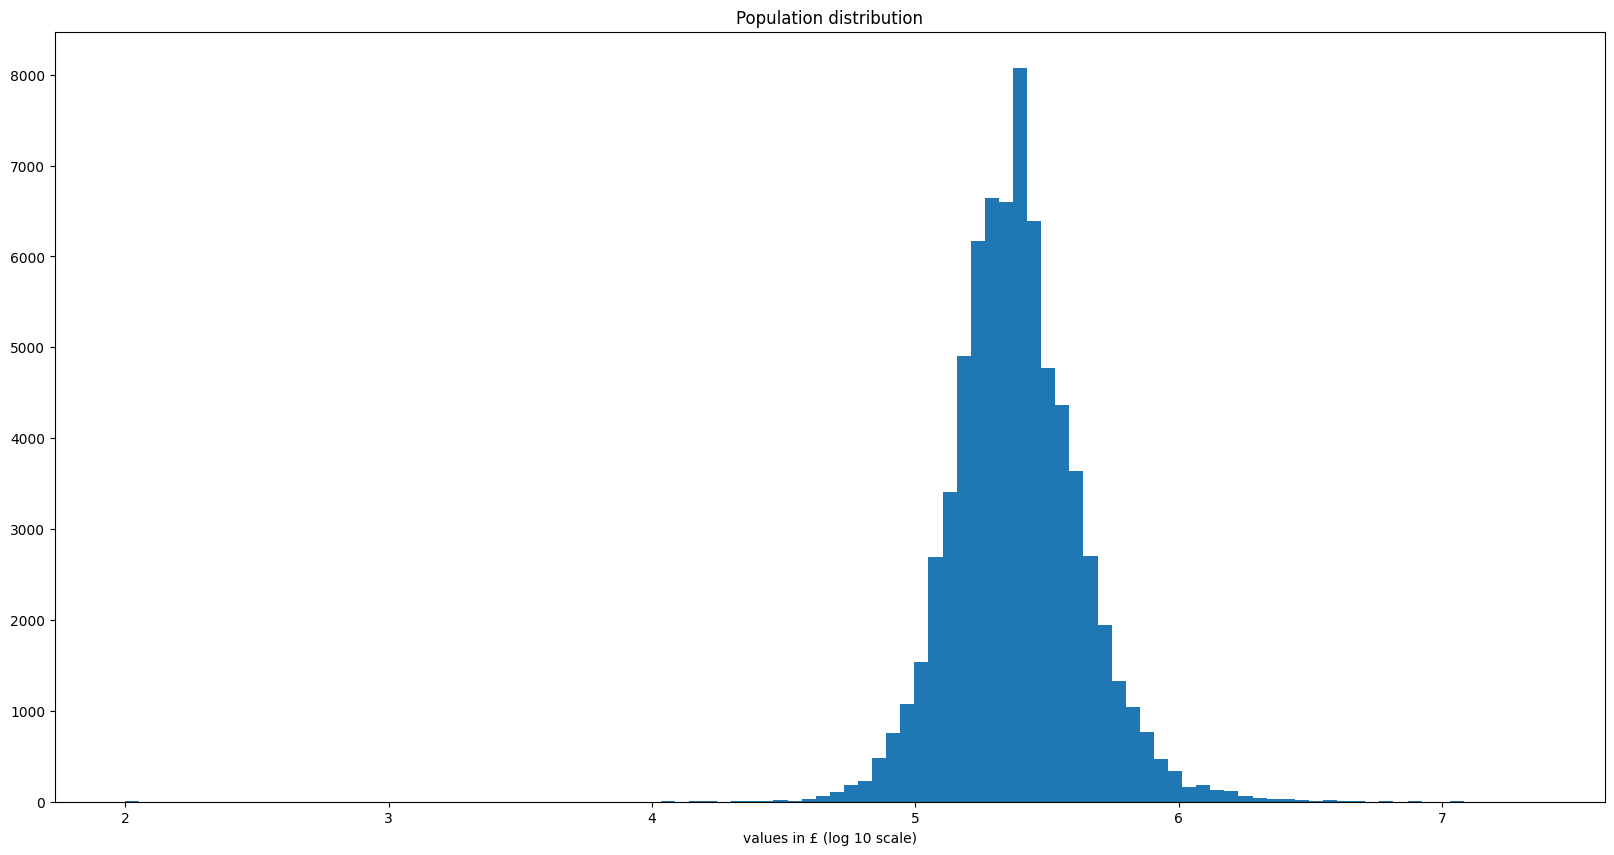

In [34]:
# Generate two normal distributions
dist1 = np.log10(population)
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist1, bins=100)
plt.title('Population distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

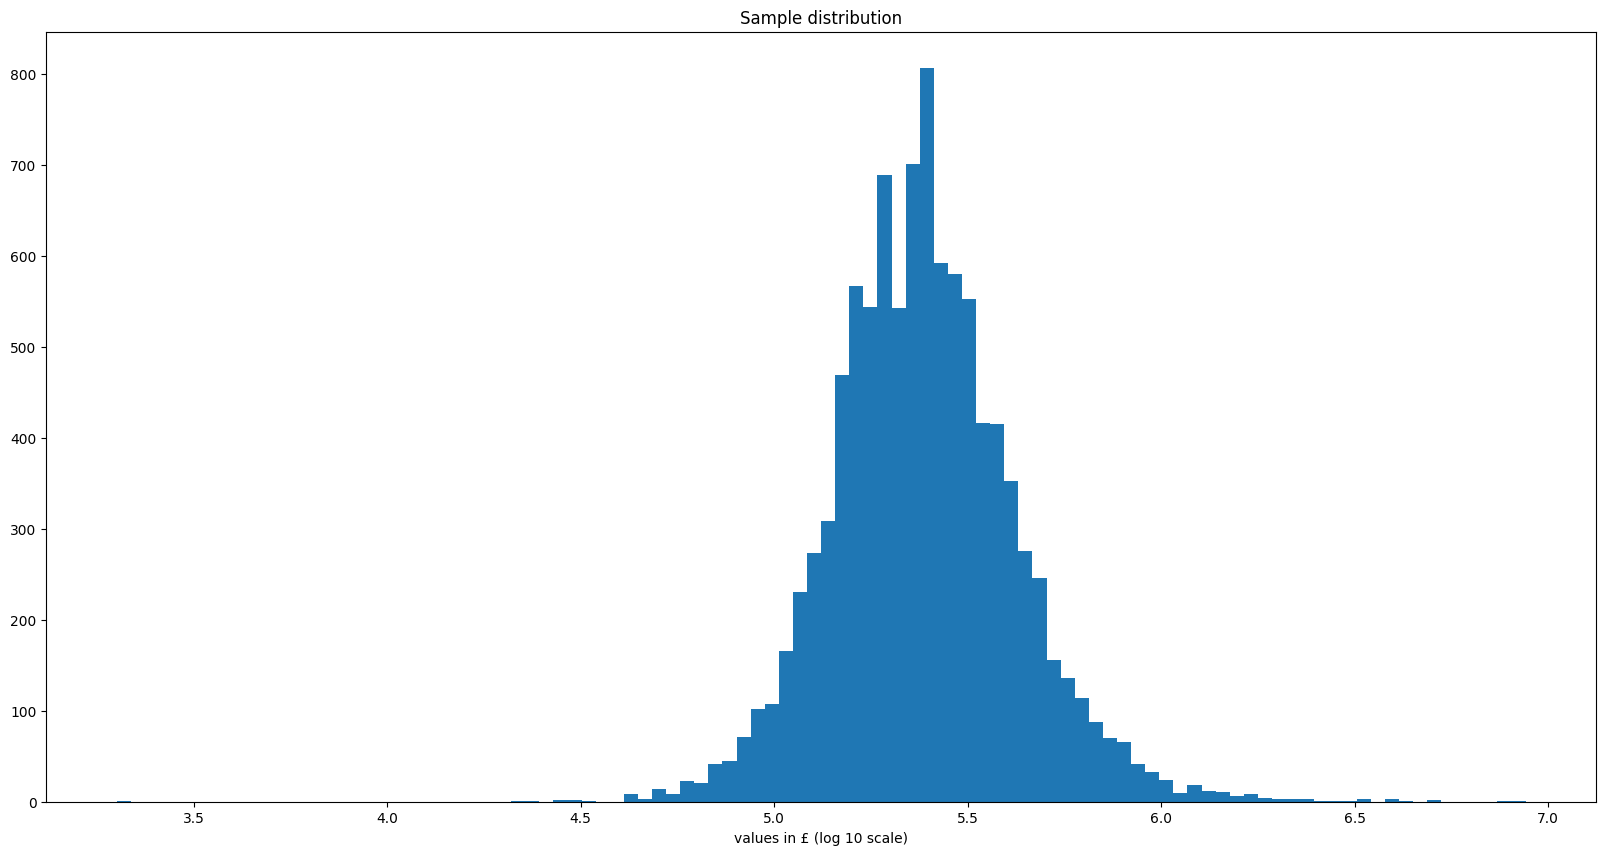

In [35]:
# Generate two normal distributions
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist2, bins=100)
plt.title('Sample distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

In [36]:

d = cohend(population, sample)
print('Cohens d: %.3f' % d)

Cohens d: 0.001


### Sample no 5 : 30000 items



In [37]:
sample_sizes= int(3e4)
sample =  pd.Series(random.sample(population, sample_sizes))
sample_mean = sample.mean()
sample_std  = sample.std(ddof = 1)
print("Population mean                : " , pop_mean)
print("Population standard deviation  : " , pop_std)
print("Sample mean                    : " , sample_mean)
print("Sample standard deviation      : " , sample_std)


Population mean                :  288745.5937364679
Population standard deviation  :  291620.51628526766
Sample mean                    :  289107.2007666667
Sample standard deviation      :  301609.3890980736


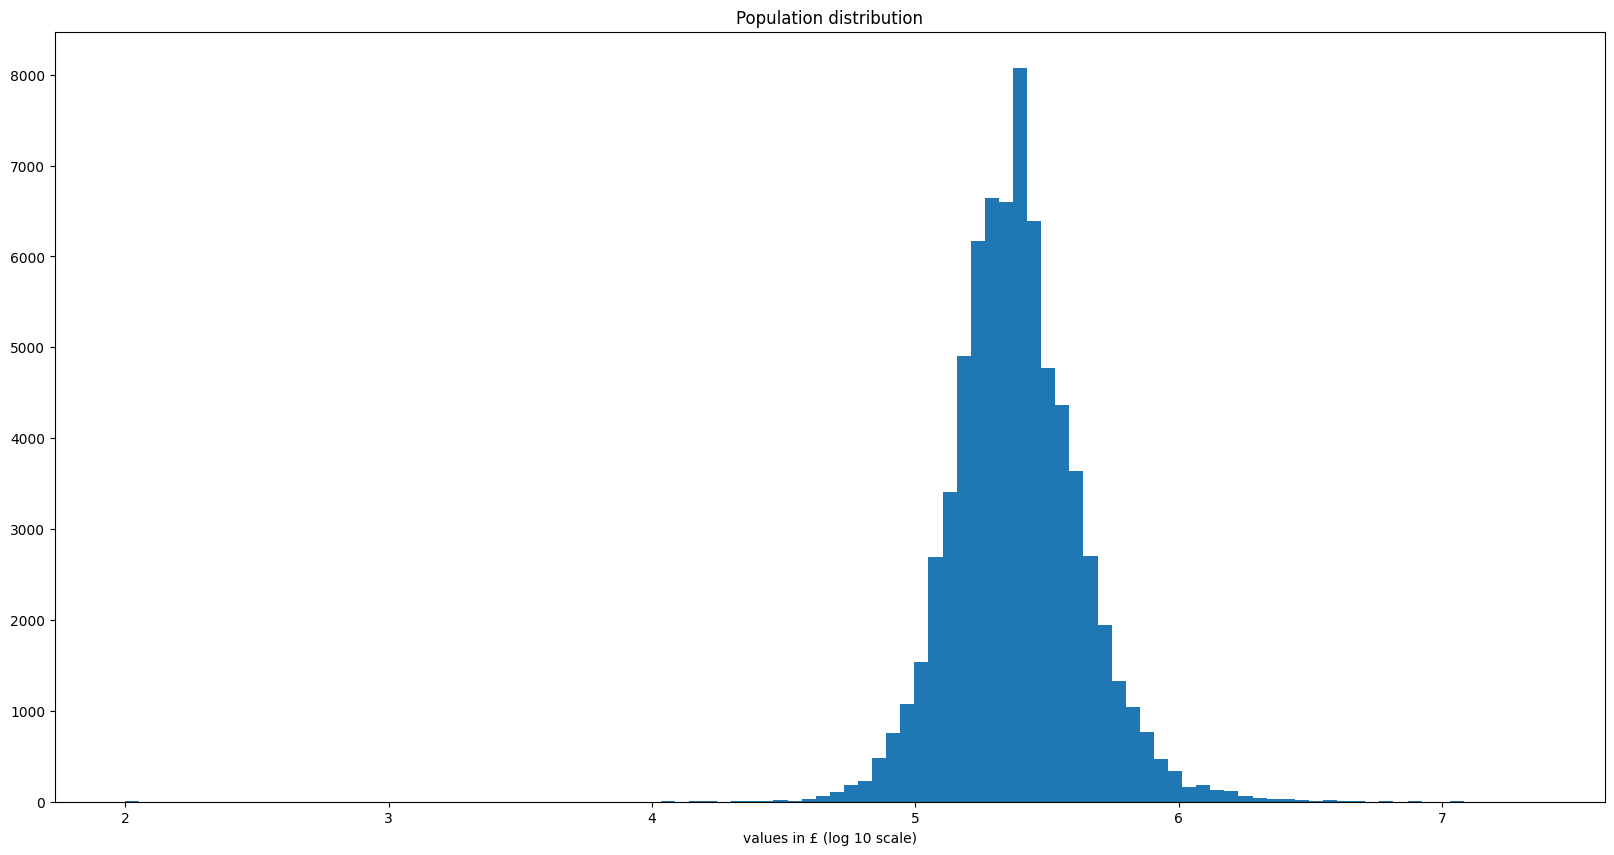

In [38]:
# Generate two normal distributions
dist1 = np.log10(population)
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist1, bins=100)
plt.title('Population distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

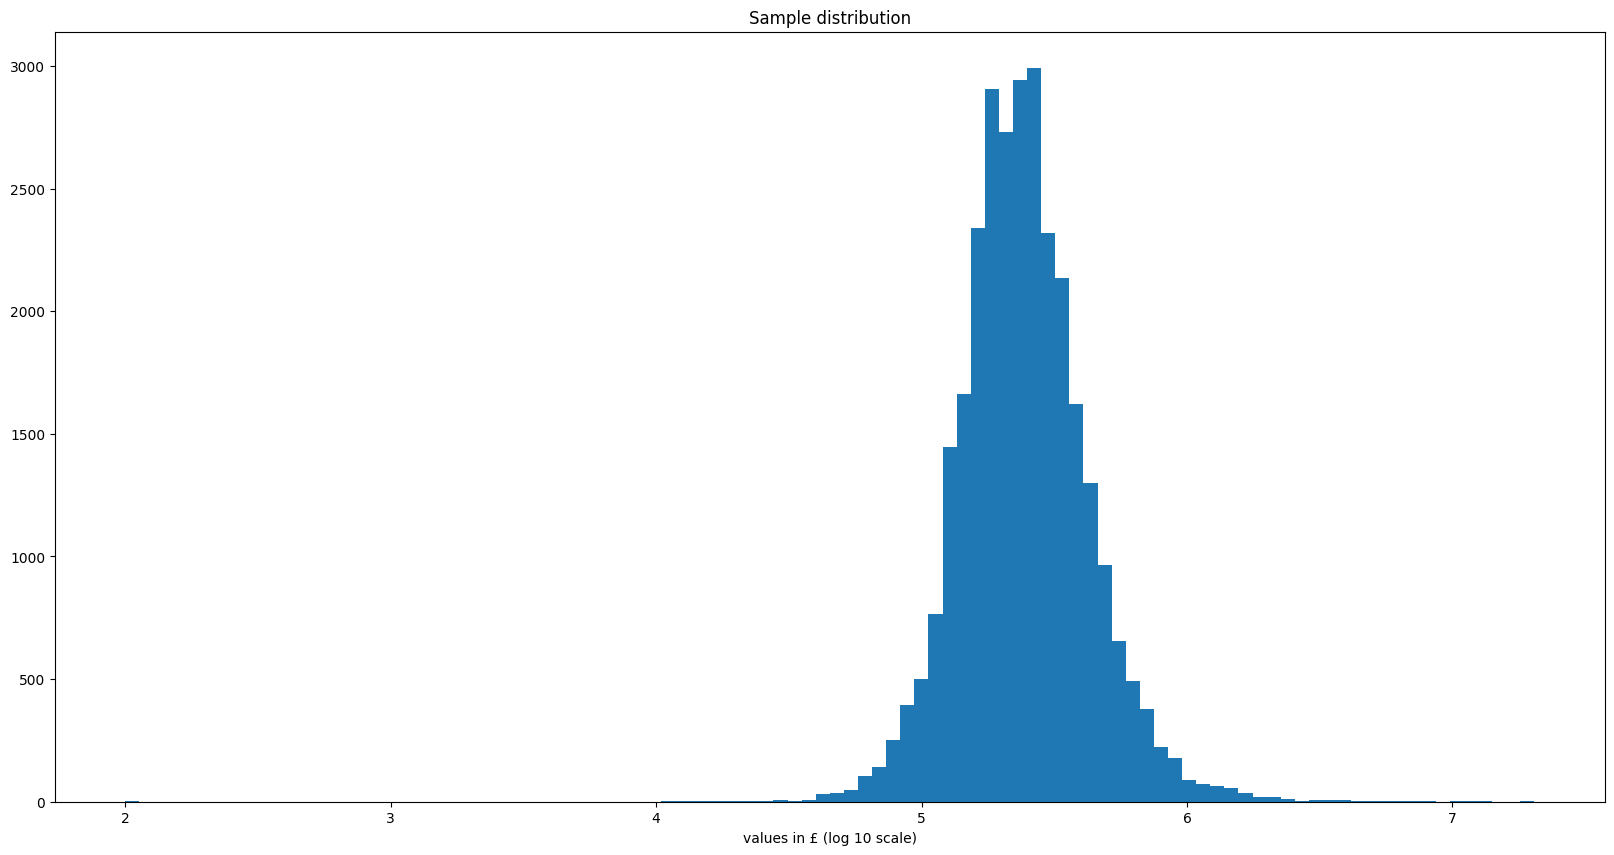

In [39]:
# Generate two normal distributions
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist2, bins=100)
plt.title('Sample distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

In [40]:

d = cohend(population, sample)
print('Cohens d: %.3f' % d)

Cohens d: -0.001


### Random values outside the population


In [41]:
sample_sizes= int(3e4)

sample =  pd.Series(np.random.normal(100000, 50000, sample_sizes))

sample_mean = sample.mean()
sample_std  = sample.std(ddof = 1)
print("Population mean                : " , pop_mean)
print("Population standard deviation  : " , pop_std)
print("Sample mean                    : " , sample_mean)
print("Sample standard deviation      : " , sample_std)


Population mean                :  288745.5937364679
Population standard deviation  :  291620.51628526766
Sample mean                    :  99791.5836509999
Sample standard deviation      :  50150.5538281233


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


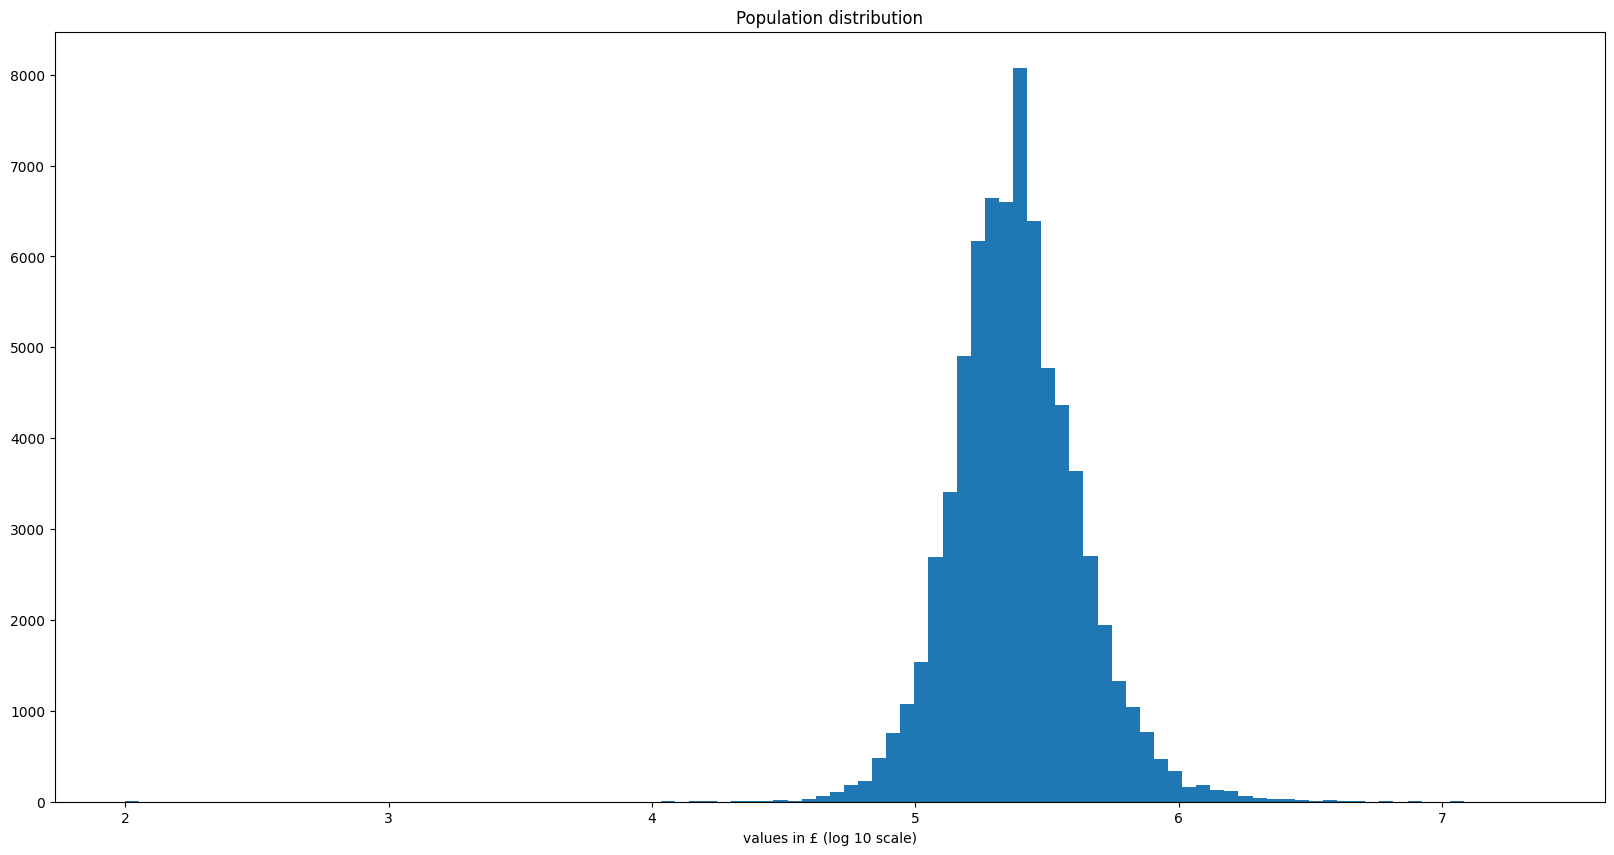

In [42]:
# Generate two normal distributions
dist1 = np.log10(population)
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist1, bins=100)
plt.title('Population distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
/usr/local/lib/python3.11/dist-packages/numpy/lib/histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


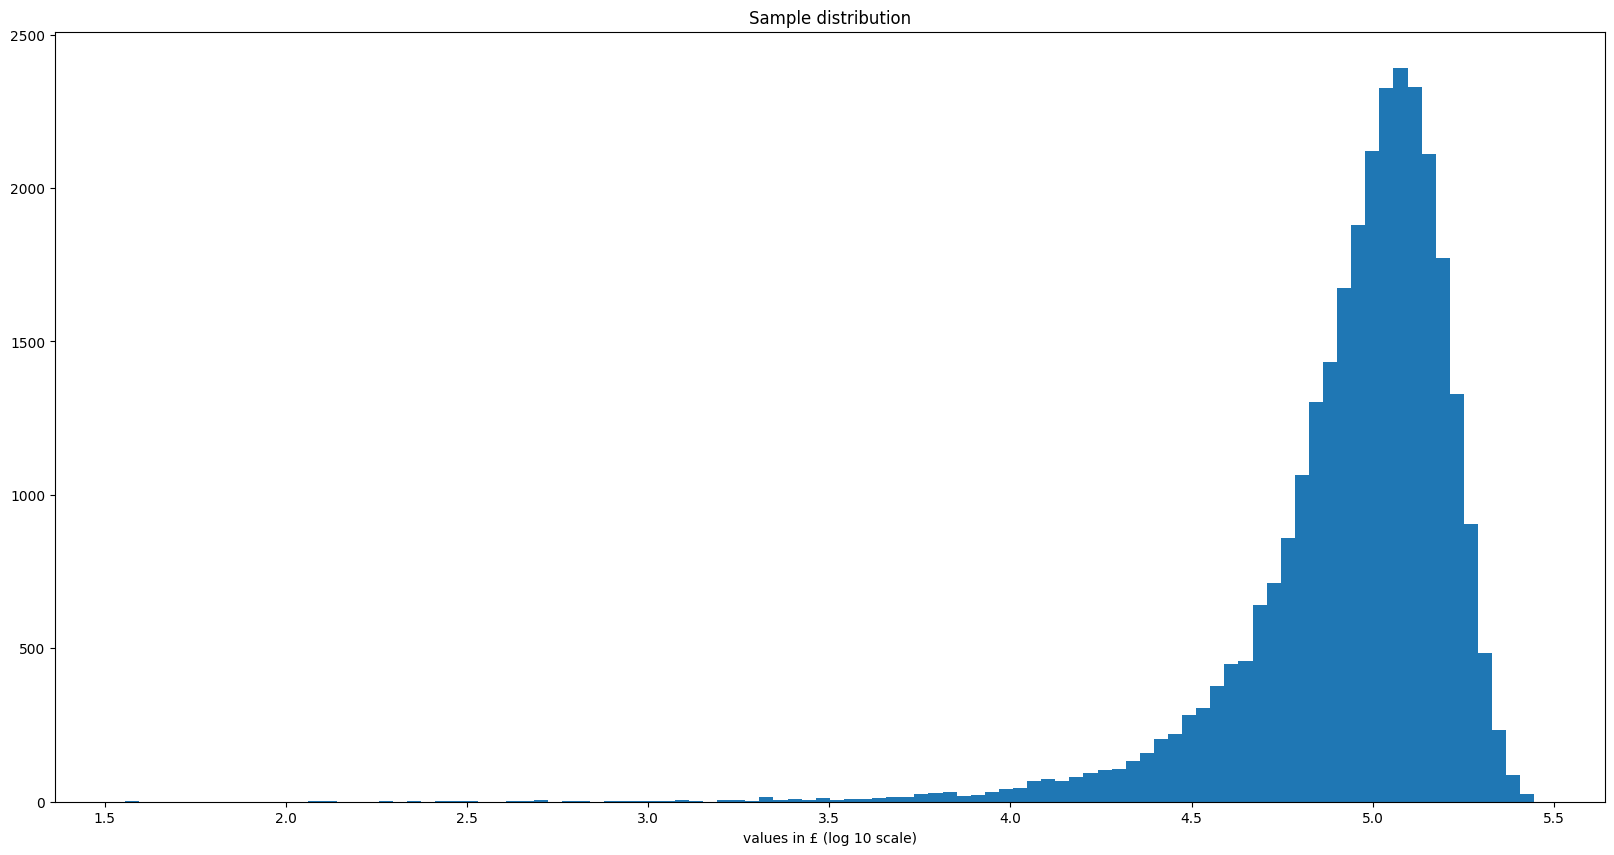

In [43]:
# Generate two normal distributions
dist2 = np.log10(sample)


# We can set the number of bins with the *bins* keyword argument.

plt.hist(dist2, bins=100)
plt.title('Sample distribution')
plt.xlabel("values in £ (log 10 scale)")
plt.show()

In [44]:

d = cohend(population, sample)
print('Cohens d: %.3f' % d)

Cohens d: 0.767
